In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [31]:
# --- Load Dataset ---
df = pd.read_csv("Datasets/loan_train.csv")   

In [32]:
# --- Handle Missing Data ---
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [33]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nHead:\n", df.head())

Shape: (255347, 18)
Columns: ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

Head:
        LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3         

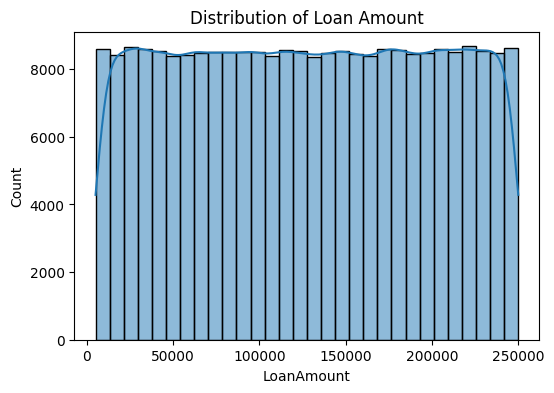

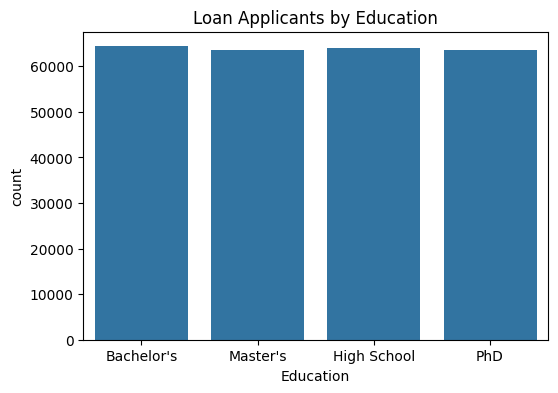

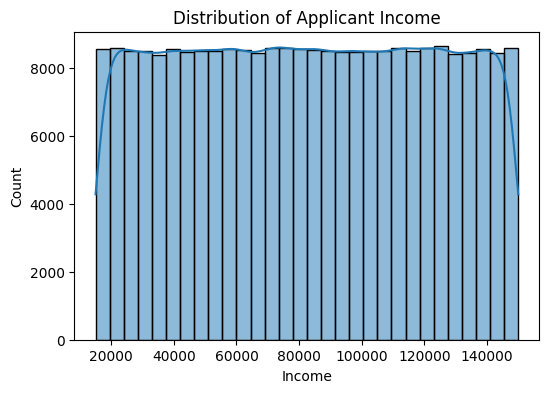

In [24]:
# --- Visualizations ---
plt.figure(figsize=(6,4))
sns.histplot(df["LoanAmount"], bins=30, kde=True)
plt.title("Distribution of Loan Amount")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Education", data=df)
plt.title("Loan Applicants by Education")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["Income"], bins=30, kde=True)   # <-- use Income, not ApplicantIncome
plt.title("Distribution of Applicant Income")
plt.show()

In [25]:
# --- Prepare Features & Target ---
X = df[["Income", "LoanAmount", "CreditScore", "Education", "Age"]]
X = pd.get_dummies(X, drop_first=True)   # encode categorical
y = df["Default"]   # target column

In [26]:
# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# --- Logistic Regression ---
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [28]:
print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))


Logistic Regression Accuracy: 0.8844722929312708
Confusion Matrix:
 [[45170     0]
 [ 5900     0]]


In [29]:
# --- Decision Tree ---
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [30]:
print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))


Decision Tree Accuracy: 0.8844722929312708
Confusion Matrix:
 [[44981   189]
 [ 5711   189]]
